In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-25 093321.png to Screenshot 2026-09-25 093321.png


In [ ]:
filename = list(uploaded.keys())[0]

image = Image.open(filename)
image = image.convert("RGB")
image = image.resize((396, 396))

image = np.array(image)

print("Image shape:", image.shape)

Image shape: (396, 396, 3)


In [ ]:
pixels = image.reshape(-1, 3)

print("Pixel data shape:", pixels.shape)

Pixel data shape: (156816, 3)


In [ ]:
k = 16

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

KMeans(n_clusters=16, n_init=10, random_state=42)

In [ ]:
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

compressed_pixels = np.clip(
    compressed_pixels.astype(np.uint8),
    0,
    255
)

compressed_image = compressed_pixels.reshape(396, 396, 3)

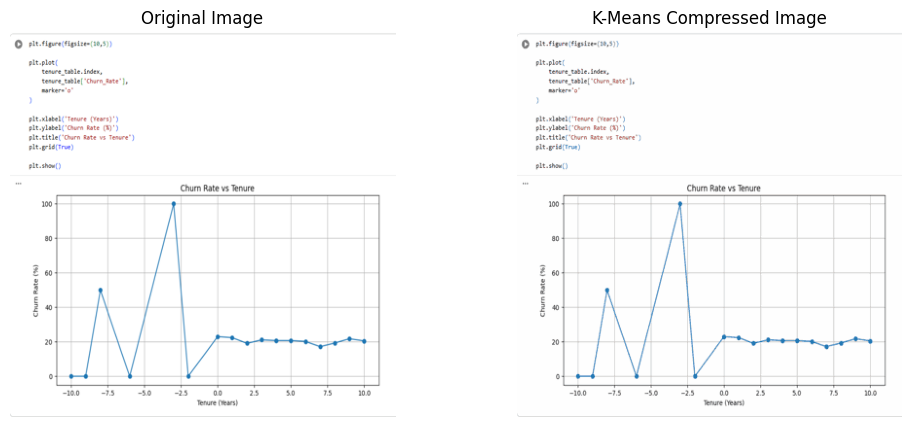

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.title("K-Means Compressed Image")
plt.axis("off")

plt.show()

In [ ]:
compressed_img = Image.fromarray(compressed_image)

compressed_img.save("compressed_image.jpg")

print("Compressed image saved successfully!")

Compressed image saved successfully!


In [ ]:
from google.colab import files

files.download("compressed_image.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>